In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import requests
import time
import math
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error

# Import các chỉ báo kỹ thuật
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

plt.style.use('seaborn-v0_8')

Using device: cpu


In [2]:
class BinanceDataLoader:
    def __init__(self):
        self.base_url = "https://fapi.binance.com/fapi/v1/klines"

    def fetch_data(self, symbol="BTCUSDT", interval="1h", start_str=None, end_str=None):
        all_data = []
        params = {"symbol": symbol, "interval": interval, "limit": 1500}
        
        if start_str:
            start_ts = int(pd.Timestamp(start_str).timestamp() * 1000)
            params["startTime"] = start_ts
            
        end_ts = int(pd.Timestamp(end_str).timestamp() * 1000) if end_str else int(time.time() * 1000)

        print(f"Đang tải dữ liệu {symbol} từ {start_str}...", end=" ")
        
        while True:
            try:
                response = requests.get(self.base_url, params=params)
                data = response.json()
                
                if not data or not isinstance(data, list):
                    break
                
                df = pd.DataFrame(data, columns=[
                    "timestamp", "open", "high", "low", "close", "volume",
                    "close_time", "q_vol", "trades", "taker_base", "taker_quote", "ignore"
                ])
                
                # Convert kiểu dữ liệu
                cols = ["open", "high", "low", "close", "volume"]
                df[cols] = df[cols].astype(float)
                df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")
                
                all_data.append(df)
                
                # Kiểm tra điều kiện dừng
                last_ts = df.iloc[-1]["timestamp"]
                if last_ts >= end_ts or len(df) < 100:
                    break
                    
                # Cập nhật startTime cho batch tiếp theo
                params["startTime"] = int(last_ts) + 1
                time.sleep(0.1) # Tránh bị chặn IP
                
            except Exception as e:
                print(f"\nLỗi tải dữ liệu: {e}")
                break

        if not all_data:
            return pd.DataFrame()
            
        final_df = pd.concat(all_data, ignore_index=True)
        final_df = final_df.set_index("datetime").sort_index()
        
        # Cắt đúng khoảng thời gian yêu cầu
        if end_str:
            final_df = final_df[:end_str]
            
        print(f"-> Hoàn tất: {len(final_df)} nến.")
        return final_df

def load_and_process_sentiment(csv_path):
    """Đọc file sentiment và gom nhóm theo giờ"""
    print(f"Đang xử lý file sentiment: {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # 1. Chuyển đổi cột Date
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    
    # 2. Resample về khung 1 Giờ (1H)
    df_resampled = df['Accurate Sentiments'].resample('1h').mean()
    df_resampled.name = 'sentiment'
    
    return df_resampled

In [3]:
def apply_sentiment_decay(series, decay_factor=0.9):
    """Giảm dần tác động của tin tức theo thời gian"""
    arr = series.values.copy()
    for i in range(1, len(arr)):
        if arr[i] == 0:
            arr[i] = arr[i-1] * decay_factor
    return pd.Series(arr, index=series.index)

def prepare_dataset_optimized(sentiment_file, symbol="BTCUSDT", window_size=24):
    # 1. Load Data
    series_sentiment = load_and_process_sentiment(sentiment_file)
    
    start_date = series_sentiment.index.min().strftime('%Y-%m-%d')
    end_date = series_sentiment.index.max().strftime('%Y-%m-%d')
    
    loader = BinanceDataLoader()
    df_price = loader.fetch_data(symbol, interval="1h", start_str=start_date, end_str=end_date)
    
    # 2. Merge & Resample
    df_price.index = pd.to_datetime(df_price.index)
    df_full = df_price.resample('1H').ffill()
    
    df_merged = df_full.join(series_sentiment, how='left')
    df_merged['sentiment'] = df_merged['sentiment'].fillna(0)
    df_merged['sentiment'] = apply_sentiment_decay(df_merged['sentiment'], decay_factor=0.9)

    # 3. Feature Engineering
    # Technical Indicators
    df_merged["rsi"] = RSIIndicator(close=df_merged["close"], window=14).rsi()
    df_merged["macd"] = MACD(close=df_merged["close"]).macd_diff()
    df_merged["bb_width"] = BollingerBands(close=df_merged["close"], window=20, window_dev=2).bollinger_wband()
    df_merged['volume_log'] = np.log1p(df_merged['volume'])

    # TARGET: Log Return (Dự đoán % thay đổi giá)
    # Log Return t = ln(Price_t / Price_t-1)
    df_merged['log_ret'] = np.log(df_merged['close'] / df_merged['close'].shift(1))
    
    # Target là Log Return của giờ TIẾP THEO
    df_merged['target'] = df_merged['log_ret'].shift(-1)

    # Xóa NaN
    df_merged.dropna(inplace=True)
    print(f"Features: {df_merged.columns.tolist()}")

    # 4. Scaling
    feature_cols = ['log_ret', 'volume_log', 'sentiment', 'rsi', 'macd', 'bb_width']
    
    scaler_X = RobustScaler()
    scaler_y = RobustScaler()

    X_scaled = scaler_X.fit_transform(df_merged[feature_cols])
    
    # Scale Target
    y_raw = df_merged['target'].values.reshape(-1, 1)
    y_scaled = scaler_y.fit_transform(y_raw)

    # 5. Sliding Window
    X_data, y_data = [], []
    for i in range(window_size, len(X_scaled)):
        X_data.append(X_scaled[i-window_size:i, :])
        y_data.append(y_scaled[i])
        
    X_tensor = torch.FloatTensor(np.array(X_data))
    y_tensor = torch.FloatTensor(np.array(y_data))
    
    # LƯU Ý QUAN TRỌNG:
    # Lưu lại giá Close tại thời điểm cuối của mỗi window để phục vụ việc tính ngược lại giá USD
    # Index tương ứng: từ dòng `window_size` đến hết
    last_closes = df_merged['close'].values[window_size:]

    return X_tensor, y_tensor, scaler_X, scaler_y, df_merged.index[window_size:], last_closes, feature_cols

In [4]:
FILE_NAME = 'bitcoin_sentiments_21_24.csv' # Đảm bảo file này đã upload
WINDOW_SIZE = 24

try:
    # Gọi hàm prepare
    (X, y, scaler_X, scaler_y, 
     time_index, last_closes, feature_cols) = prepare_dataset_optimized(FILE_NAME, window_size=WINDOW_SIZE)
    
    # Chia Train/Test (80/20)
    split = int(0.8 * len(X))
    
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Chia cả time_index và last_closes để dùng cho việc vẽ biểu đồ
    time_test = time_index[split:]
    closes_test = last_closes[split:]
    
    print(f"\nKích thước tập Train: {X_train.shape}")
    print(f"Kích thước tập Test: {X_test.shape}")
    print(f"Feature cols ({len(feature_cols)}): {feature_cols}")

except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file '{FILE_NAME}'.")

Đang xử lý file sentiment: bitcoin_sentiments_21_24.csv...
Đang tải dữ liệu BTCUSDT từ 2021-11-05... 

-> Hoàn tất: 25032 nến.
Features: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'q_vol', 'trades', 'taker_base', 'taker_quote', 'ignore', 'sentiment', 'rsi', 'macd', 'bb_width', 'volume_log', 'log_ret', 'target']


C:\Users\hoang\AppData\Local\Temp\ipykernel_6764\1547399424.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_full = df_price.resample('1H').ffill()



Kích thước tập Train: torch.Size([19979, 24, 6])
Kích thước tập Test: torch.Size([4995, 24, 6])
Feature cols (6): ['log_ret', 'volume_log', 'sentiment', 'rsi', 'macd', 'bb_width']


In [5]:
class CryptoPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1, dropout=0.2):
        super(CryptoPredictor, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.output_dim = output_dim
        self.dropout = dropout
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        last_out = out[:, -1, :]
        prediction = self.fc(last_out)
        return prediction
    
    def save_model(self, path, scaler_X, scaler_y, feature_cols, window_size, extra_info=None):
        checkpoint = {
            'model_config': {
                'input_dim': self.input_dim, 'hidden_dim': self.hidden_dim,
                'num_layers': self.num_layers, 'output_dim': self.output_dim,
                'dropout': self.dropout,
            },
            'model_state_dict': self.state_dict(),
            'feature_cols': feature_cols,
            'window_size': window_size,
            # Lưu tham số của scaler thay vì object để tránh lỗi pickle
            'scaler_X_params': {
                'center': scaler_X.center_.tolist(), 'scale': scaler_X.scale_.tolist()
            },
            'scaler_y_params': {
                'center': scaler_y.center_.tolist(), 'scale': scaler_y.scale_.tolist()
            }
        }
        if extra_info: checkpoint['extra_info'] = extra_info
        
        os.makedirs(os.path.dirname(path) if os.path.dirname(path) else '.', exist_ok=True)
        torch.save(checkpoint, path)
        print(f"Model saved to: {path}")

    @classmethod
    def load_model(cls, path, device):
        checkpoint = torch.load(path, map_location=device)
        config = checkpoint['model_config']
        model = cls(**config)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)
        return model, checkpoint


Bắt đầu huấn luyện...
Epoch [5/10], Loss: 1.810338, LR: 0.001000
Epoch [10/10], Loss: 1.810806, LR: 0.000500

=> RMSE trên tập Test: 367.95 USD
Model saved to: crypto_predictor.pt


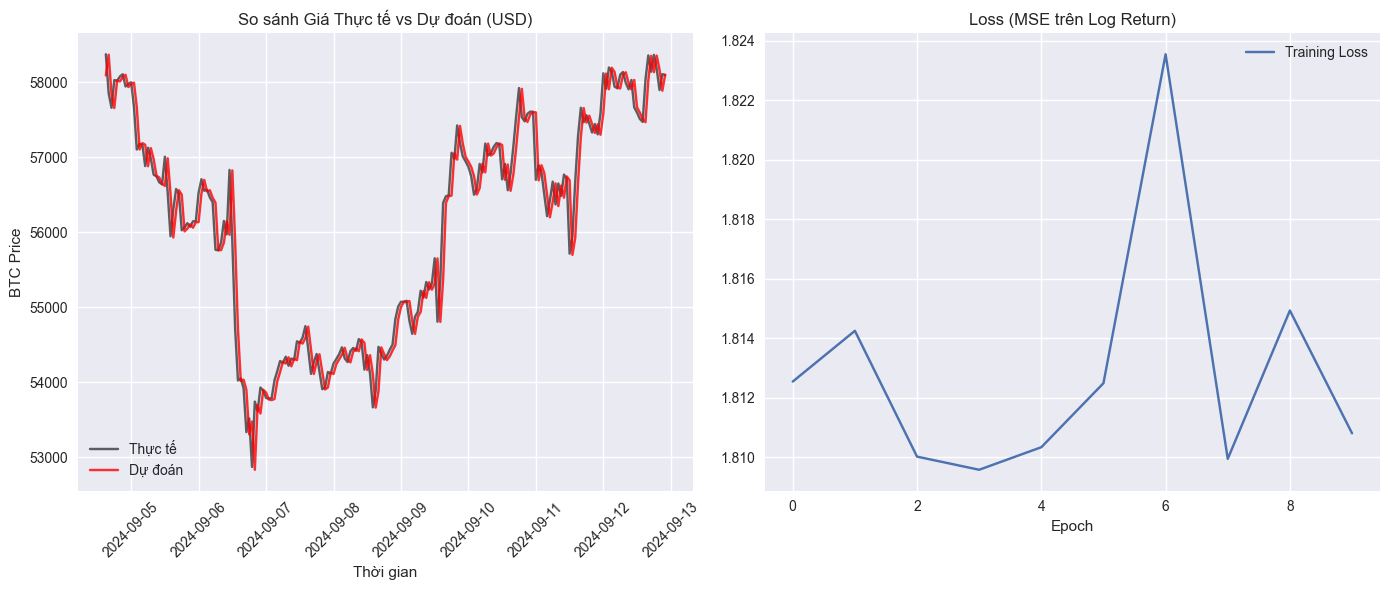

In [12]:
def train_and_evaluate(save_model_path="crypto_predictor.pt"):
    # 1. Config
    input_dim = X_train.shape[2]
    hidden_dim = 64
    num_layers = 2
    batch_size = 64
    epochs = 10
    lr = 0.001
    
    model = CryptoPredictor(input_dim, hidden_dim, num_layers, dropout=0.2).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    
    print("\nBắt đầu huấn luyện...")
    loss_history = []
    
    # 2. Training Loop
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        scheduler.step(avg_loss)
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

    # 3. Evaluation & Price Reconstruction
    model.eval()
    with torch.no_grad():
        # Dự đoán Log Return (đã scale)
        pred_scaled = model(X_test.to(DEVICE)).cpu().numpy()
        actual_scaled = y_test.numpy()
        
    # Inverse Scale để lấy Log Return gốc
    pred_log_ret = scaler_y.inverse_transform(pred_scaled).flatten()
    actual_log_ret = scaler_y.inverse_transform(actual_scaled).flatten()
    
    # --- TÍNH LẠI GIÁ (Price Reconstruction) ---
    # Công thức: Price_t+1 = Price_t * exp(Log_Return)
    # closes_test chính là Price_t (giá tại thời điểm cuối của window input)
    
    pred_price = closes_test * np.exp(pred_log_ret)
    actual_price = closes_test * np.exp(actual_log_ret)
    
    # Tính RMSE trên giá thật (USD)
    rmse = math.sqrt(mean_squared_error(actual_price, pred_price))
    print(f"\n=> RMSE trên tập Test: {rmse:.2f} USD")
    
    # 4. Save Model
    model.save_model(save_model_path, scaler_X, scaler_y, feature_cols, WINDOW_SIZE, {'rmse': rmse})
    
    # 5. Plotting
    plt.figure(figsize=(14, 6))
    
    # Biểu đồ giá
    plt.subplot(1, 2, 1)
    look_back = 200 # Chỉ vẽ 200 điểm cuối cho dễ nhìn
    plt.plot(time_test[-look_back:], actual_price[-look_back:], label='Thực tế', color='black', alpha=0.6)
    plt.plot(time_test[-look_back:], pred_price[-look_back:], label='Dự đoán', color='red', alpha=0.8)
    plt.title("So sánh Giá Thực tế vs Dự đoán (USD)")
    plt.xlabel("Thời gian")
    plt.ylabel("BTC Price")
    plt.legend()
    plt.xticks(rotation=45)
    
    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(loss_history, label='Training Loss')
    plt.title("Loss (MSE trên Log Return)")
    plt.xlabel("Epoch")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Chạy
if 'X_train' in locals():
    train_and_evaluate()